# SANKUNG FATTY

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn import datasets
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier

In [3]:
data=pd.read_csv("carseats.csv")
data.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [4]:
# To add a new column called 'Class' based on the condition
data['Class'] = data['Sales'].apply(lambda x: 1 if x >= 8 else 0)

# Now we need to drop the 'Sales' column
data.drop('Sales', axis=1, inplace=True)

# print the updated dataframe
data.head()

,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US,Class
0,138,73,11,276,120,Bad,42,17,Yes,Yes,1
1,111,48,16,260,83,Good,65,10,Yes,Yes,1
2,113,35,10,269,80,Medium,59,12,Yes,Yes,1
3,117,100,4,466,97,Medium,55,14,Yes,Yes,0
4,141,64,3,340,128,Bad,38,13,Yes,No,0


In [5]:
data.dtypes

CompPrice       int64
Income          int64
Advertising     int64
Population      int64
Price           int64
ShelveLoc      object
Age             int64
Education       int64
Urban          object
US             object
Class           int64
dtype: object

In [6]:
# one-hot encode the categorical variables
df = pd.get_dummies(data, columns=['ShelveLoc', 'Urban','US'])
df.head()

,CompPrice,Income,Advertising,Population,Price,Age,Education,Class,ShelveLoc_Bad,ShelveLoc_Good,ShelveLoc_Medium,Urban_No,Urban_Yes,US_No,US_Yes
0,138,73,11,276,120,42,17,1,1,0,0,0,1,0,1
1,111,48,16,260,83,65,10,1,0,1,0,0,1,0,1
2,113,35,10,269,80,59,12,1,0,0,1,0,1,0,1
3,117,100,4,466,97,55,14,0,0,0,1,0,1,0,1
4,141,64,3,340,128,38,13,0,1,0,0,0,1,1,0


In [7]:
X = df[['CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'Age', 'Education']]
y = df['Class']


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=5)

In [9]:
from sklearn.preprocessing import StandardScaler

In [10]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [11]:

from sklearn.linear_model import LogisticRegression

# fit a logistic regression model
model = LogisticRegression(random_state=0,penalty='none')
model.fit(X_train_scaled, y_train)

# predict the labels for the test set
y_pred = model.predict(X_test_scaled)

# calculate the accuracy of the model on the test set
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)


Accuracy: 0.7916666666666666


In [12]:
clf20 = KNeighborsClassifier(n_neighbors=20)
mod=clf20.fit(X_train,y_train)

In [13]:
#Create a list to store the results
cvres=[]
# Run through various values for k: use 5-fold cross validation, score with accuracy
for i in range(1,100):
    clf = KNeighborsClassifier(n_neighbors=i)
    nn = cross_validate(clf, X_train, y_train, cv=5, scoring='accuracy')
    #The test score gives an list of the accuracy on each of the five the test-folds
    cvres.append(nn['test_score'].mean())

In [14]:
nn['test_score']

array([0.625     , 0.625     , 0.625     , 0.60714286, 0.60714286])

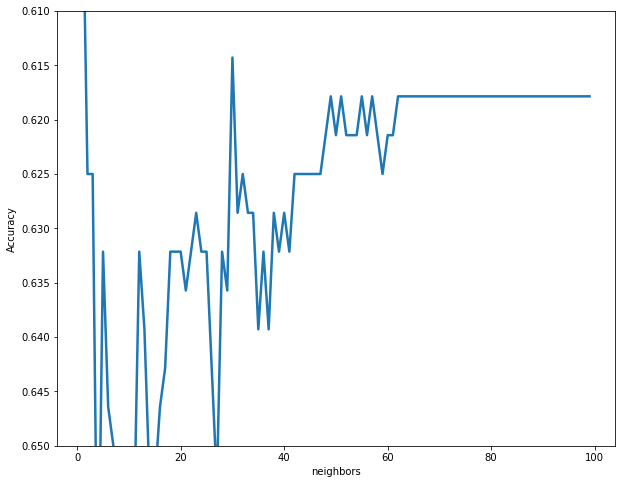

In [15]:
plt.figure(figsize=(10, 8))
plt.plot(list(range(1,100)),cvres,linewidth=2.5)
plt.ylim(.65,.61)
plt.xlabel('neighbors')
plt.ylabel('Accuracy')
plt.show()

In [16]:

# Find the index of the best score
best_idx = np.argmax(cvres)

best_idx

8

In [19]:
Final_mod = KNeighborsClassifier(n_neighbors=8)
pr=Final_mod.fit(X_train_scaled,y_train)

In [20]:
np.round(accuracy_score(pr.predict(X_test_scaled),y_test),3)

0.675

In the logistic model we have an accuracy of 0.79. This means that the logistic regression model correctly classified 79% of the samples in the test set. In other words, the model predicted the correct class for about 79 out of every 100 samples in the test set. The accuracy for the KNN Classifier is about 67%.